<a href="https://colab.research.google.com/github/ErbolTakhirov/Learning-notebooks/blob/main/statistics/statistics_lab_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Task_1
Нам дан набор данных.
* Вычислите среднее значение и размах.
* Вычислите значения квантиля 0.2. В чем смысл этой величины?
* Рассчитайте 1-й, 2-й и 3-й квартили.
* Нарисуйте руками Боксплот (усатый ящик)
* Какие значения мы сочтем за выбросы?
* Постройте Boxplot методом любой библиотеки визуализации.
* Постройте Violinplot.
* Постройте гистограмму.
* Почистите выбросы, которые выходят за рамки усов боксплота. Поменялось ли среднее значение после чистки?

In [ ]:
arr = np.array([-1, 22, 17, 12, 18, 19, 22, 13, 13, 18, 15, 12, 21, 13, 15, 21, 14, 17, 21, 19, 17,  35, 40])

<Axes: >

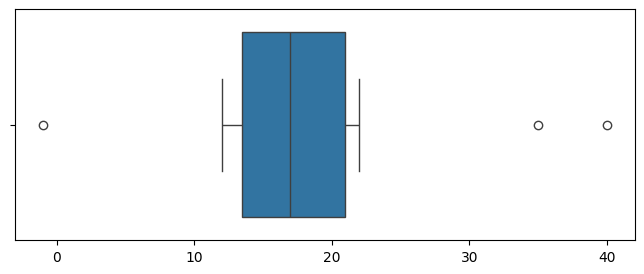

In [ ]:
plt.subplots(figsize=(8,3))

sns.boxplot(x = arr)

<Axes: >

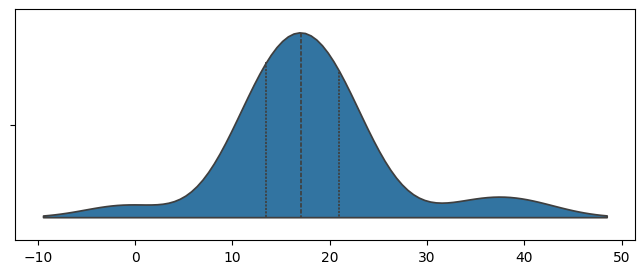

In [ ]:
plt.subplots(figsize=(8,3))
sns.violinplot(x = arr, inner='quart', split=True)

<Axes: ylabel='Count'>

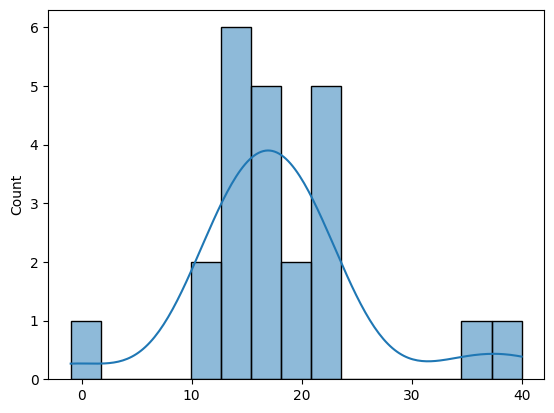

In [ ]:
sns.histplot(arr, kde=True, bins = 15)

<Axes: >

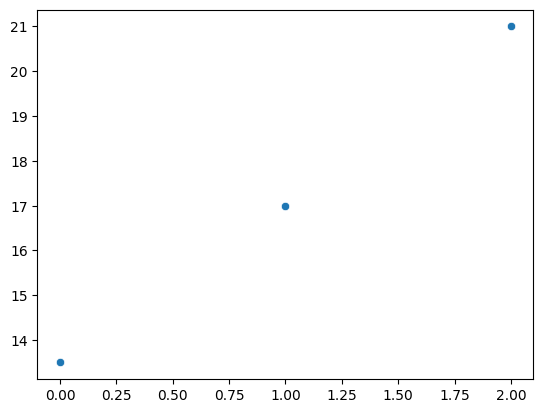

In [ ]:
sns.scatterplot(quan)

<Axes: >

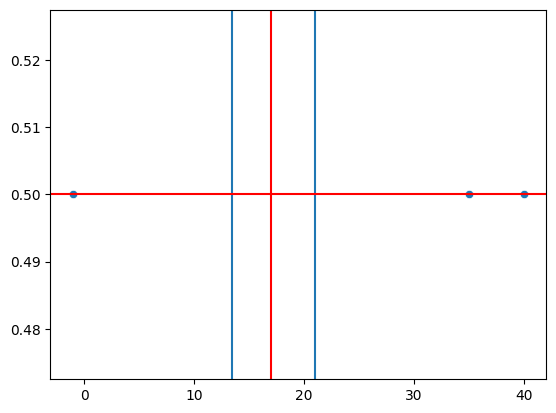

In [ ]:
plt.axvline(quan[1],color='red')
plt.axvline(quan[0], ymin = quan[0], ymax = -quan[0])
plt.axvline(quan[2])

plt.axhline(y = 0.5, xmin = quan[0], xmax = lower, color = 'red')
plt.axhline(y = 0.5, xmin = quan[2], xmax = upper, color = 'red')

sns.scatterplot(y = 0.5, x = [-1, 35, 40])

In [ ]:
upper = -(quan[2] + quan[2] * 1.5)
lower = quan[0] + quan[0] * 1.5

In [ ]:
mean_before = np.mean(arr)
mean_before

np.float64(17.956521739130434)

In [ ]:
mask_left = arr < quan[2] + 1.5 * iqr
mask_right = arr > quan[0] - 1.5 * iqr
display(mask_left, mask_right)

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True, False, False])

array([False,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True])

In [ ]:
iqr = abs(quan[0] - quan[2])

In [ ]:
arr[mask_left & mask_right]

array([12, 12, 13, 13, 13, 14, 15, 15, 17, 17, 17, 18, 18, 19, 19, 21, 21,
       21, 22, 22])

In [ ]:
mean_ = np.mean(arr[mask_left & mask_right])
mean_

np.float64(16.95)

<Axes: >

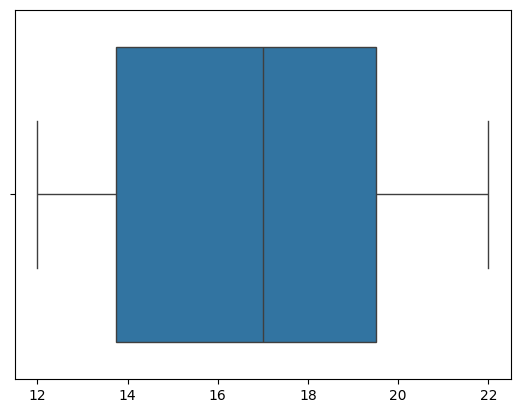

In [ ]:
sns.boxplot(x = arr[mask_left & mask_right])

<Axes: ylabel='Density'>

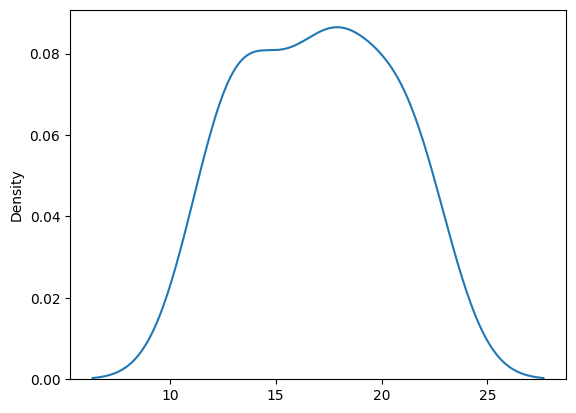

In [ ]:
sns.kdeplot(arr[mask_left & mask_right])

In [ ]:
np.mean(arr)

np.float64(17.956521739130434)

In [ ]:
np.std(arr)

np.float64(7.743037606776954)

In [ ]:
max(arr) - min(arr)

np.int64(41)

In [ ]:
np.quantile(arr, 0.2).item()
# Вероятность попадания слева от этого числа 20%

13.0

In [ ]:
quan = np.quantile(arr, [0.25, 0.5, 0.75])
quan

array([13.5, 17. , 21. ])

In [ ]:
arr.sort()

In [ ]:
np.random.choice(arr)
# 20% на то что рандомное число будет меньше квантиля 20% (то есть 13)

np.int64(-1)

In [ ]:
arr.shape

(23,)

# Task_2

Мы загрузили известный датасет Ирисы Фишера, который посвящен измерениям цветков Ириса с целью разделить их на отдельные виды. Признаки:
* 	sepal_length - длина чашелистика.
* 	sepal_width - ширина чашелистика.
*   petal_length - длина лепестка.
*   petal_width - ширина лепестка.
*   species - вид цветка.



 Давайте его поизучаем. Какими типами представлены признаки?

In [ ]:
df = sns.load_dataset('iris')
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


Давайте изучим описательную статистику количественных признаков.
* Какой из признаков имеет самыые высокие значения?
* Какой из признаков представлен наибольшей изменчивостью?
* Оцените симметричность распределений.

In [ ]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


Для визуализации мы пандас датафрейм превратили в нампай массивы.

In [ ]:
features = np.array(df.iloc[:, :-1])
features[:10] # количественные фичи

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1]])

In [ ]:
species = df.species.tolist()
species[:5] # категориальная фича

['setosa', 'setosa', 'setosa', 'setosa', 'setosa']

<Axes: >

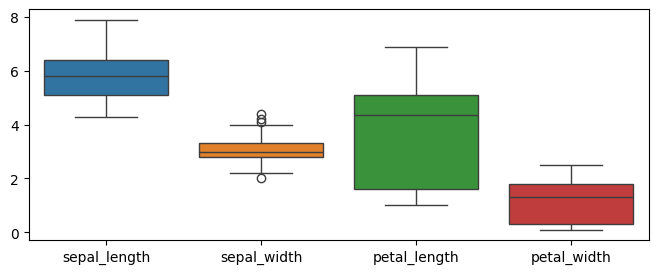

In [ ]:
plt.subplots(figsize=(8,3))
sns.boxplot(df)

<Axes: ylabel='Density'>

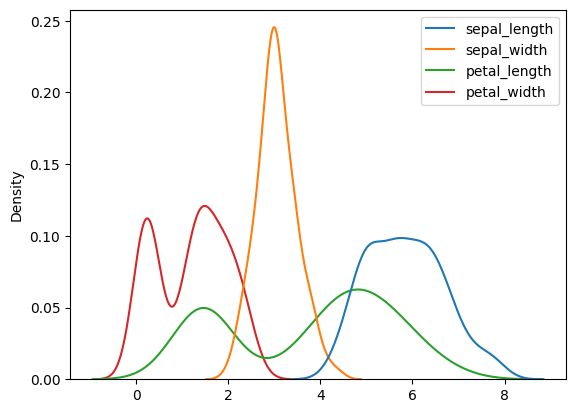

In [ ]:
sns.kdeplot(df)

## Visualization

* Постройте разные Боксплоты для отображения изменчивости количественных признаков. Можете использовать цветовую дифференциацию по категориальной переменной.
* Постройте по аналогии разные Violinplot. Поизучайте документацию к данному типу графика: https://seaborn.pydata.org/generated/seaborn.violinplot.html#seaborn.violinplot

* Постройте кривые распределения. Обратите внимание на полимодальность. (Когда в распределении не одна мода а несколько). Подумайте, почему это так?
* Постройте скаттерплоты чтобы наглядно показать наличие кластеров (групп).

# Task_3

Сопоставьте графики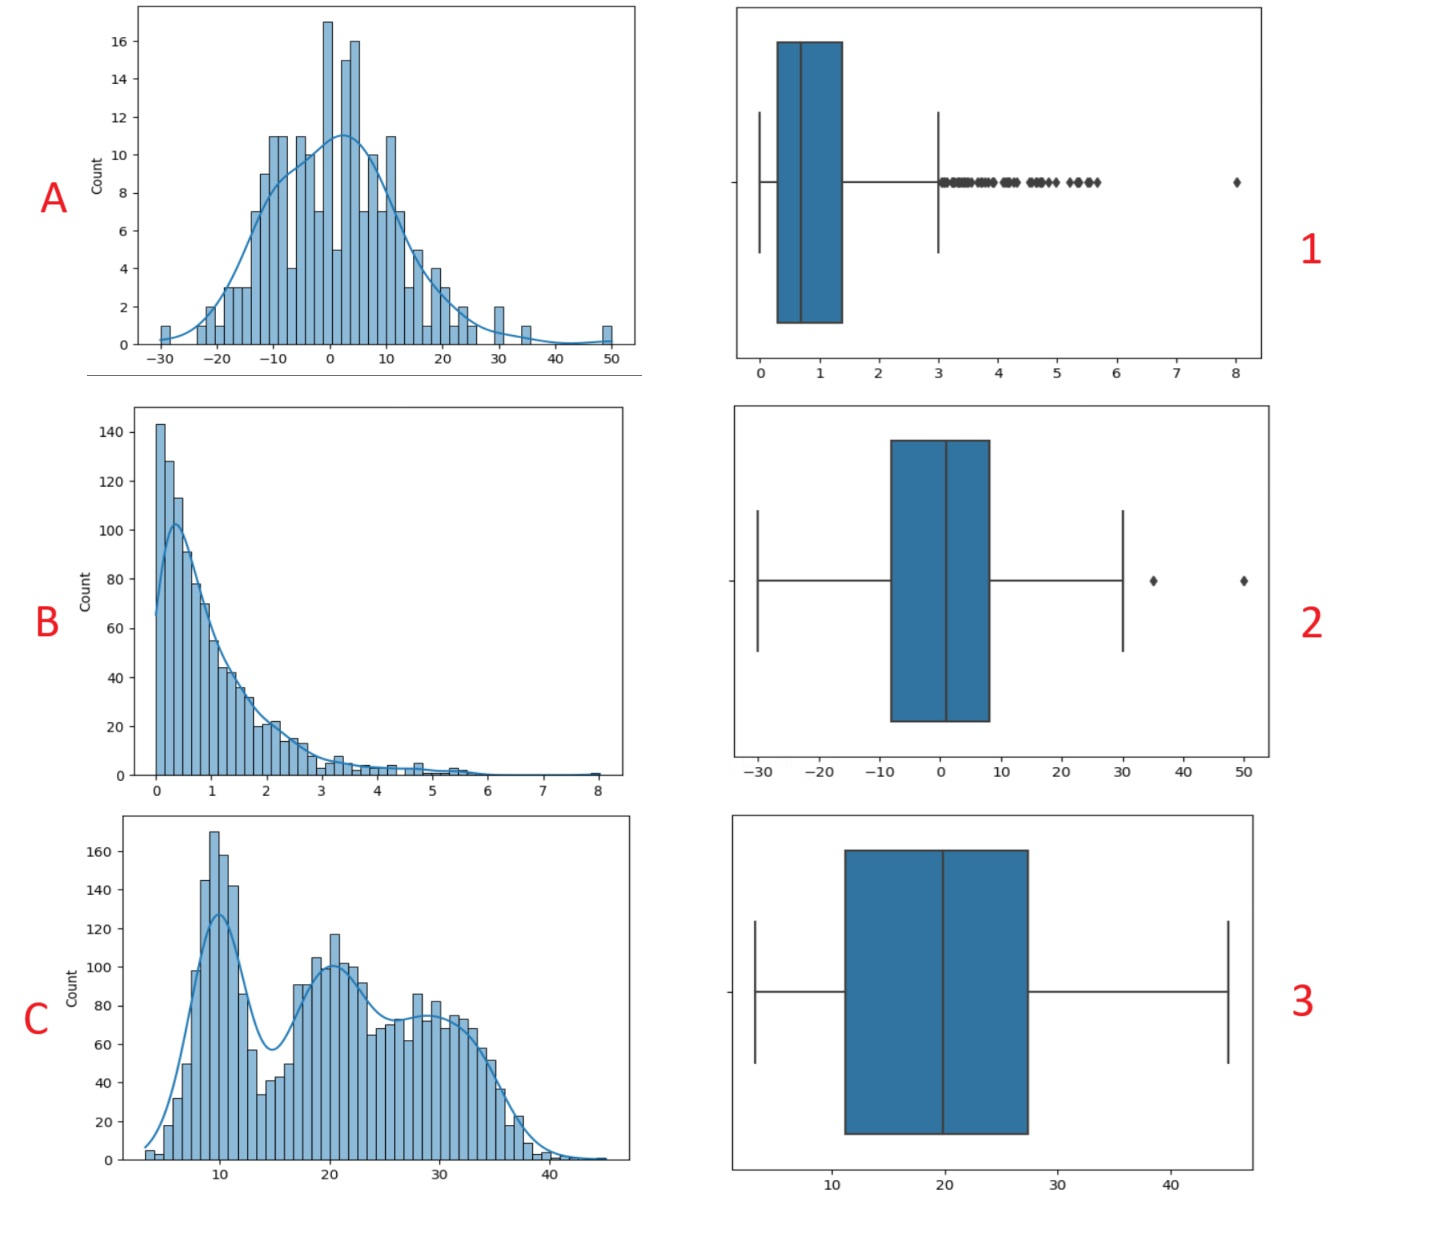

<Axes: >

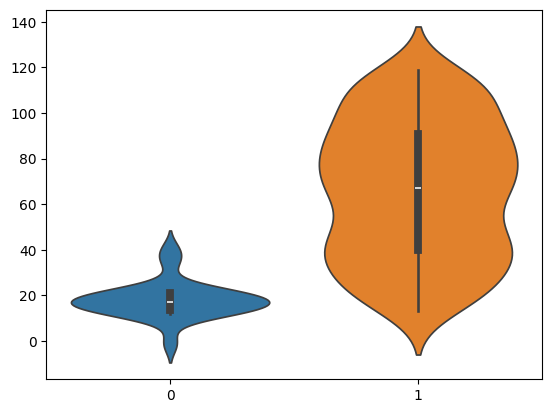

In [ ]:
sns.violinplot([arr, arr_2])

In [ ]:
arr_2 = np.random.randint(12, 120, 332)

In [ ]:
arr_4 = np.random.randn(100)*5 + 40
arr_5 = np.random.randn(100)*5 + 55

In [ ]:
arr__ = np.concatenate([arr_4, arr_5])


<Axes: ylabel='Density'>

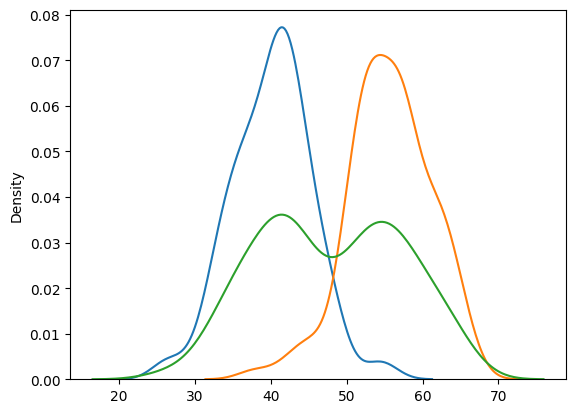

In [ ]:
sns.kdeplot(arr_4)
sns.kdeplot(arr_5)
sns.kdeplot(arr__)
# Вероятность получить какое-то значения делятся на 2, поэтому третий

<Axes: >

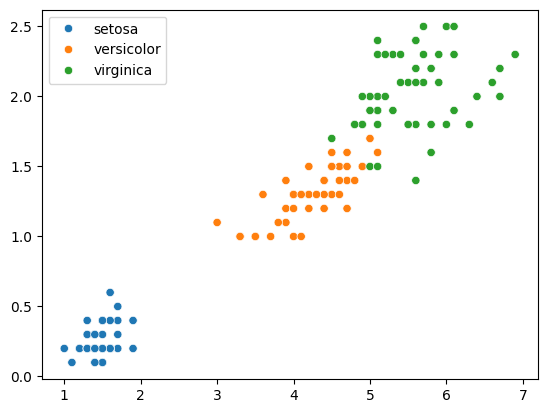

In [ ]:
sns.scatterplot(x=features[:, 2], y = features[:, 3], hue = species)

<Axes: >

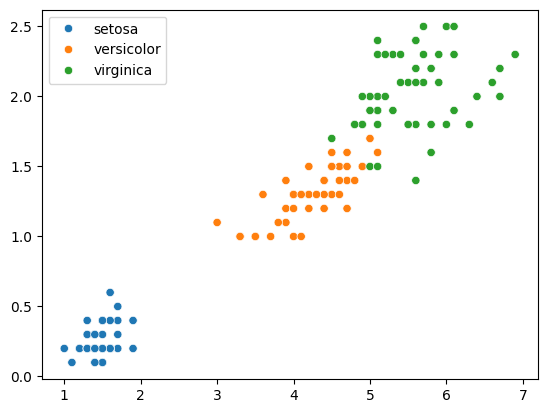

In [ ]:
sns.scatterplot(x=features[:, 2], y = features[:, 3], hue = species)
# Построить кдеплот для видов разных

<Axes: ylabel='Density'>

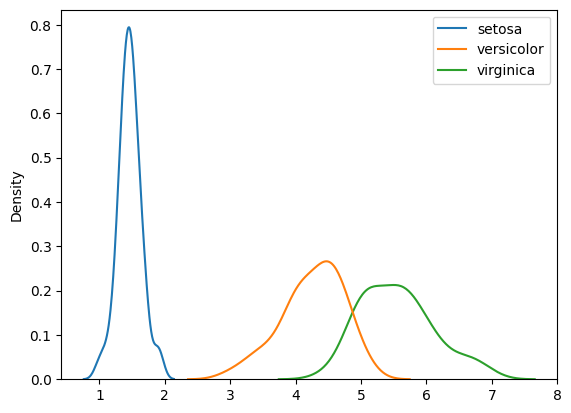

In [ ]:
sns.kdeplot(x = features[:, 2], hue = species)
# Без использования датафреймов

<Axes: ylabel='Density'>

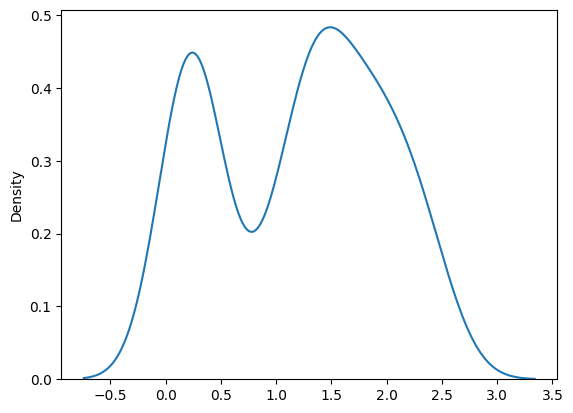

In [ ]:
sns.kdeplot(features[:, 3])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
